# MLPs For Univaraite Forecasting

In [10]:
#imports
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [14]:
import os

# Change to the Downloads folder
os.chdir(os.path.expanduser("~\\Downloads"))

# Verify current working directory
print("Current Directory:", os.getcwd())


Current Directory: C:\Users\Dell\Downloads


In [16]:
df = pd.read_excel('sales.xlsx')
df.head()

,Time_Stamp,RetailSales
0,2000-01-01,4243
1,2000-02-01,4952
2,2000-03-01,6008
3,2000-04-01,5353
4,2000-05-01,6435


In [18]:
df.set_index('Time_Stamp',inplace=True)
df.head()

,RetailSales
Time_Stamp,
2000-01-01,4243
2000-02-01,4952
2000-03-01,6008
2000-04-01,5353
2000-05-01,6435


In [20]:
df.isna().sum()

RetailSales    0
dtype: int64

In [22]:
df.shape

(192, 1)

Hyperparameters:

n_input: The number of lag observations to use as input to the model.

n_nodes: The number of nodes to use in the hidden layer.
    
n_epochs: The number of times to expose the model to the whole training dataset.

n_batch: The number of samples within an epoch after which the weights are updated.

In [26]:
#hyperparameters
n_input = 12
n_nodes = 100
n_epochs = 100

In [28]:
# split a univariate dataset into train/test sets
def train_test_split(data, n_test):
  return data[:-n_test], data[-n_test:]

In [30]:
# transform list into supervised learning format
def series_to_supervised(data, n_in, n_out=1):
  df = pd.DataFrame(data)
  cols = list()
  # input sequence (t-n, ... t-1)
  for i in range(n_in, 0, -1):
    cols.append(df.shift(i))
  # forecast sequence (t, t+1, ... t+n)
  for i in range(0, n_out):
    cols.append(df.shift(-i))
  # put it all together
  agg = pd.concat(cols, axis=1)
  # drop rows with NaN values
  agg.dropna(inplace=True)
  
  return agg.values

series_to_supervised(df.values, 12)

array([[ 4243.,  4952.,  6008., ...,  6520.,  6678.,  5082.],
       [ 4952.,  6008.,  5353., ...,  6678.,  5082.,  5216.],
       [ 6008.,  5353.,  6435., ...,  5082.,  5216.,  5893.],
       ...,
       [11817., 10470., 13310., ..., 11224., 12022., 11983.],
       [10470., 13310.,  8400., ..., 12022., 11983., 11506.],
       [13310.,  8400.,  9062., ..., 11983., 11506., 14183.]])

In [32]:
train, test = train_test_split(df, 21)

print(f"train shape : {train.shape}, test shape : {test.shape}")

train shape : (171, 1), test shape : (21, 1)


In [34]:
data = series_to_supervised(train, n_input)
train_x, train_y = data[:, :-1], data[:, -1]
train_x.shape, train_y.shape

((159, 12), (159,))

In [36]:
train_x.shape[0] * train_x.shape[1]

1908

In [38]:
train_x.shape

(159, 12)

In [40]:
# define model

class TimeSeriesMLPModel(nn.Module):

    def __init__(self, n_input, n_nodes) -> None:
        super().__init__()
        self.lm_linear = nn.Sequential(
            nn.Linear(in_features=n_input, out_features=n_nodes),
            nn.ReLU(),
            nn.Linear(in_features=n_nodes, out_features=1),
            )
    def forward(self, X):
        
        B, T = X.shape
        logits = self.lm_linear(X)
        return logits

In [42]:
n_input = 12
n_nodes = 100
mlp_model  = TimeSeriesMLPModel(n_input, n_nodes)

In [44]:
#loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(mlp_model.parameters())

In [45]:
#convert datatype
train_x, train_y = torch.tensor(train_x, dtype=torch.float32), torch.tensor(train_y, dtype=torch.float32)


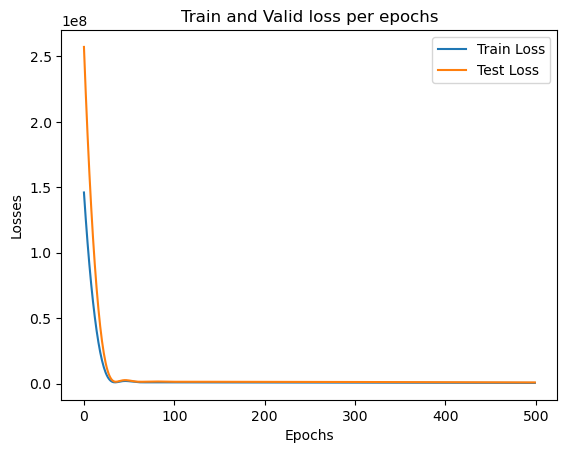

In [52]:
#training loop
n_epochs = 500
train_losses = []
test_losses = []

for _ in range(n_epochs):
    
    optimizer.zero_grad()
    logits = mlp_model.forward(train_x)
    loss = criterion(logits.view(-1), train_y)
    train_losses.append(loss.item())
    #validation
    #history
    with torch.no_grad():
        history = train_x[-1].tolist() + train_y[-1][None].tolist()

        y_pred_values = []
        y_true = []
        for i in range(len(test)):

            test_points = torch.tensor(history[-n_input:], dtype=torch.float32).view(1, n_input)
            yhat =  mlp_model.forward(test_points)
            history.append(test.iloc[i, 0])
            y_pred_values.append(yhat.item())
            y_true.append(test.iloc[i, 0])

        y_pred_values = torch.tensor(y_pred_values, dtype=torch.float32)
        y_true = torch.tensor(y_true, dtype=torch.float32)
        test_loss = criterion(y_pred_values, y_true)
        test_losses.append(test_loss.item())
    loss.backward()
    optimizer.step()


plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')

# Adding labels and legend
plt.xlabel('Epochs')
plt.ylabel('Losses')
plt.title('Train and Valid loss per epochs')
plt.legend()

# Show the plot
plt.show()

# Model Evaluation

In [55]:
train_x[0], train_y[0]

(tensor([4243., 4952., 6008., 5353., 6435., 6673., 5636., 6630., 5887., 6322.,
         6520., 6678.]),
 tensor(5082.))

In [57]:
train_x[1], train_y[1]

(tensor([4952., 6008., 5353., 6435., 6673., 5636., 6630., 5887., 6322., 6520.,
         6678., 5082.]),
 tensor(5216.))

In [59]:
test = test.values

In [61]:
train_y[-1].to

<function Tensor.to>

In [63]:
train_y[-1][None].tolist()

[10055.0]

In [65]:
#history
history = train_x[-1].tolist() + train_y[-1][None].tolist()
len(history)
torch.tensor(history[-n_input:], dtype=torch.float32).shape

torch.Size([12])

In [67]:
test[0]

array([10977], dtype=int64)

In [69]:
#history
history = train_x[-1].tolist() + train_y[-1][None].tolist()

y_pred_values = []
y_true = []
for i in range(len(test)):

    test_points = torch.tensor(history[-n_input:], dtype=torch.float32).view(1, n_input)
    yhat =  mlp_model.forward(test_points)
    history.append(test[i][0])
    y_pred_values.append(yhat.item())
    y_true.append(test[i][0])

y_pred_values = torch.tensor(y_pred_values, dtype=torch.float32)
y_true = torch.tensor(y_true, dtype=torch.float32)
test_loss = criterion(y_pred_values, y_true)

print(f"Test loss : {test_loss}")

Test loss : 878567.4375


# Time Series Forecasting with LSTMs

In [72]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# This relates to plotting datetime values with matplotlib:
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [74]:
df.head()

,RetailSales
Time_Stamp,
2000-01-01,4243
2000-02-01,4952
2000-03-01,6008
2000-04-01,5353
2000-05-01,6435


# Plot the time series

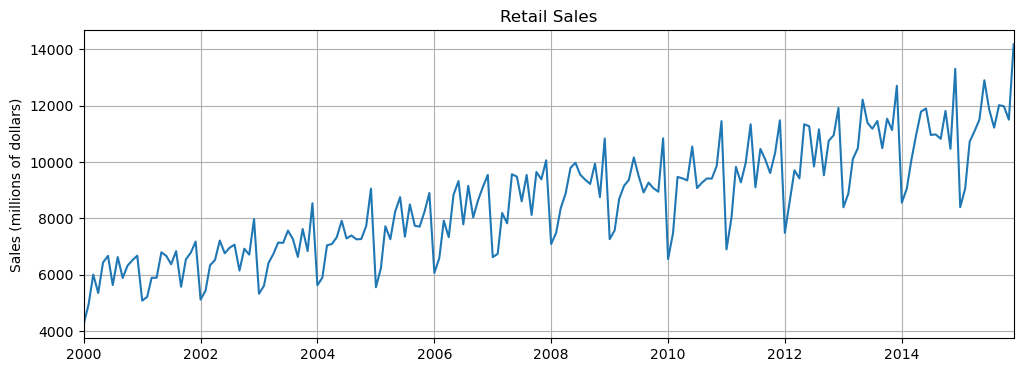

In [77]:
plt.figure(figsize=(12,4))
plt.title('Retail Sales')
plt.ylabel('Sales (millions of dollars)')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['RetailSales'])
plt.show()

# Data preparartion

In the next steps we'll divide the data into train/test sets, then normalize the training values so that they fall between -1 and 1 (to improve training). We'll train the model, then predict into a period that matches the test set. Finally, we'll forecast into an unknown future.

In [87]:
# Extract values from the source .csv file
y = df['RetailSales'].values.astype(float)

# Define a test size
test_size = 12

# Create train and test sets
train_set = y[:-test_size]
test_set = y[-test_size:]

In [89]:
print(f"shape of train_set : {train_set.shape}")
print(f"shape of test_set : {test_set.shape}")

shape of train_set : (180,)
shape of test_set : (12,)


It's worth noting that in our previous exercise the train and test sets were tensors. Here they're numpy arrays. This is because one of the steps we're about to perform outputs an array, and we'd have to turn it into a tensor anyway.

# Normalize the data

The formula for normalizing data around zero is:

$$
X_{\text{norm}} = \frac{X - \mu}{\sigma}
$$


where $ \mu $ is the population mean, and $ \sigma $ is the population standard deviation.

Ultimately we want to perform min/max feature scaling so that our values fall between -1 and 1, as this makes hyperparameters converge faster.
The formula for this would be:

$$
X' = a + \frac{(X - X_{\min})(b - a)}{X_{\max} - X_{\min}}
$$


where a = -1 and b = 1

We can use scikit-learn to do this, with sklearn.preprocessing.MinMaxScaler()

NOTE: We only want to normalize the training set to avoid data leakage. If we include the test set then the higher average values of the test set could become part of the signal in the training set. There's a good article on data leakage here.

After using transformed data to train the model and generate predictions, we'll inverse_transform the predicted values so that we can compare them to the actual test data.

In [100]:
from sklearn.preprocessing import MinMaxScaler

# Instantiate a scaler with a feature range from -1 to 1
scaler = MinMaxScaler(feature_range=(-1, 1))

In [102]:
# Normalize the training set
train_norm = scaler.fit_transform(train_set.reshape(-1, 1))

In [104]:
train_norm[:10]

array([[-1.        ],
       [-0.84360869],
       [-0.61067608],
       [-0.75515606],
       [-0.51648836],
       [-0.46399029],
       [-0.69273188],
       [-0.47347524],
       [-0.63736627],
       [-0.54141392]])

# Data preparation for LSTM training

Here we'll create our list of (seq/label) tuples from the training set. Recall that an LSTM consumes a window of samples toward the first prediction, so the size of our training set will become ((192 - test_size) - window_size).

In [109]:
# Convert train_norm from an array to a tensor
train_norm = torch.FloatTensor(train_norm).view(-1)

# Define a window size
window_size = 12

# Define function to create seq/label tuples
def input_data(seq, ws):  # ws is the window size
    out = []
    L = len(seq)
    for i in range(L-ws):
        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1]
        out.append((window,label))
    return out

# Apply the input_data function to train_norm
train_data = input_data(train_norm,window_size)
len(train_data)  # this should equal 325-12-12

168

In [111]:
train_data[:2]

[(tensor([-1.0000, -0.8436, -0.6107, -0.7552, -0.5165, -0.4640, -0.6927, -0.4735,
          -0.6374, -0.5414, -0.4977, -0.4629]),
  tensor([-0.8149])),
 (tensor([-0.8436, -0.6107, -0.7552, -0.5165, -0.4640, -0.6927, -0.4735, -0.6374,
          -0.5414, -0.4977, -0.4629, -0.8149]),
  tensor([-0.7854]))]

# Define the model

We will be using an LSTM layer of size (1, 1000).

In [115]:
class SalesPredictor(nn.Module):

    def __init__(self, input_size=1, hidden_size=100, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size)
        self.linear = nn.Linear(hidden_size, output_size)
        self.hidden = (torch.zeros(1, 1, self.hidden_size),
                       torch.zeros(1, 1, self.hidden_size))
    def forward(self, seq):
        out, self.hidden = self.lstm(seq.view(len(seq), 1, -1), self.hidden)
        pred = self.linear(out.view(len(seq), -1))
        return pred[-1]

# Instantiate the model and define the loss and optimizer

In [120]:
predictorModel = SalesPredictor()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(predictorModel.parameters(), lr=0.001)

predictorModel

SalesPredictor(
  (lstm): LSTM(1, 100)
  (linear): Linear(in_features=100, out_features=1, bias=True)
)

# Model's training

In [123]:
epochs = 100

import time
start_time = time.time()

for epoch in range(epochs):
    
    # extract the sequence & label from the training data
    for seq, y_train in train_data:
        
        # reset the parameters and hidden states
        optimizer.zero_grad()
        predictorModel.hidden = (torch.zeros(1,1,predictorModel.hidden_size),
                        torch.zeros(1,1,predictorModel.hidden_size))
        
        y_pred = predictorModel(seq)
        
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        
    # print training result
    print(f'Epoch: {epoch+1:2} Loss: {loss.item():10.8f}')
    
print(f'\nDuration: {time.time() - start_time:.0f} seconds')

Epoch:  1 Loss: 0.40948477
Epoch:  2 Loss: 0.17689142
Epoch:  3 Loss: 0.56962299
Epoch:  4 Loss: 0.33226085
Epoch:  5 Loss: 0.36011627
Epoch:  6 Loss: 0.36228099
Epoch:  7 Loss: 0.40167224
Epoch:  8 Loss: 0.36644676
Epoch:  9 Loss: 0.37426126
Epoch: 10 Loss: 0.36264336
Epoch: 11 Loss: 0.36066532
Epoch: 12 Loss: 0.36358562
Epoch: 13 Loss: 0.36842063
Epoch: 14 Loss: 0.36346838
Epoch: 15 Loss: 0.39133900
Epoch: 16 Loss: 0.38167891
Epoch: 17 Loss: 0.39443135
Epoch: 18 Loss: 0.39426410
Epoch: 19 Loss: 0.40357327
Epoch: 20 Loss: 0.40911245
Epoch: 21 Loss: 0.41063967
Epoch: 22 Loss: 0.41348949
Epoch: 23 Loss: 0.40179664
Epoch: 24 Loss: 0.39870164
Epoch: 25 Loss: 0.38353103
Epoch: 26 Loss: 0.27991912
Epoch: 27 Loss: 0.23195031
Epoch: 28 Loss: 0.18971832
Epoch: 29 Loss: 0.16711472
Epoch: 30 Loss: 0.16858204
Epoch: 31 Loss: 0.13967969
Epoch: 32 Loss: 0.15044227
Epoch: 33 Loss: 0.16477750
Epoch: 34 Loss: 0.17661092
Epoch: 35 Loss: 0.17044608
Epoch: 36 Loss: 0.16665752
Epoch: 37 Loss: 0.17797500
E

# Model's inference

In [126]:
future = 12

# Add the last window of training values to the list of predictions
preds = train_norm[-window_size:].tolist()

# Set the model to evaluation mode
predictorModel.eval()

for i in range(future):
    seq = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad():
        predictorModel.hidden = (torch.zeros(1,1,predictorModel.hidden_size),
                        torch.zeros(1,1,predictorModel.hidden_size))
        preds.append(predictorModel(seq).item())

In [128]:
preds[window_size:] 

[0.003117486834526062,
 0.1274251639842987,
 0.3715277910232544,
 0.5966224074363708,
 0.721730649471283,
 0.7484425902366638,
 0.5205745697021484,
 0.556835412979126,
 0.5450286865234375,
 0.7574271559715271,
 0.4412715435028076,
 1.0233354568481445]

Let's invert the prediction so that we can compare them with original values in test sets.

Note that inverse_transform uses the most recently applied parameters; we can rescale based on the test data, but not on the previous training data.

In [145]:
true_prediction = scaler.inverse_transform(np.array(preds[window_size:]).reshape(1, -1))
true_prediction = true_prediction.squeeze()

In [147]:
df['RetailSales'][-12:]

Time_Stamp
2015-01-01     8400
2015-02-01     9062
2015-03-01    10722
2015-04-01    11107
2015-05-01    11508
2015-06-01    12904
2015-07-01    11869
2015-08-01    11224
2015-09-01    12022
2015-10-01    11983
2015-11-01    11506
2015-12-01    14183
Name: RetailSales, dtype: int64

# Plot the results

Our original data contains a datetime index, but our predicted values do not. We can create a range of dates using NumPy that are spaced one month apart using dtype='datetime64[M]', and then store them with day values to match our dataset with .astype('datetime64[D]').

In [155]:
# Remember that the stop date has to be later than the last predicted value.
x = np.arange('2015-01-01', '2016-01-01', dtype='datetime64[M]').astype('datetime64[D]')
x

array(['2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01',
       '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01',
       '2015-09-01', '2015-10-01', '2015-11-01', '2015-12-01'],
      dtype='datetime64[D]')

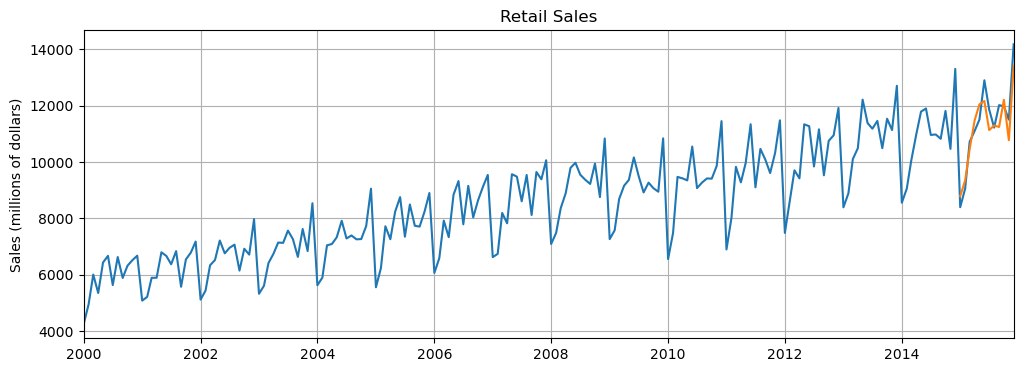

In [159]:
plt.figure(figsize=(12,4))
plt.title('Retail Sales')
plt.ylabel('Sales (millions of dollars)')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['RetailSales'])
plt.plot(x,true_prediction)
plt.show()

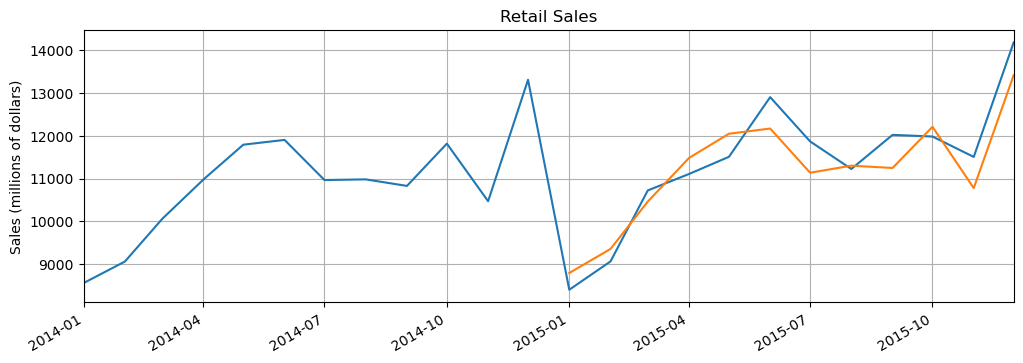

In [163]:
# Plot the end of the graph
fig = plt.figure(figsize=(12,4))
plt.title('Retail Sales')
plt.ylabel('Sales (millions of dollars)')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
fig.autofmt_xdate()

# Select the end of the graph with slice notation:
plt.plot(df['RetailSales']['2014-01-01':])
plt.plot(x,true_prediction)
plt.show()

In [165]:
train_norm

tensor([-1.0000, -0.8436, -0.6107, -0.7552, -0.5165, -0.4640, -0.6927, -0.4735,
        -0.6374, -0.5414, -0.4977, -0.4629, -0.8149, -0.7854, -0.6360, -0.6358,
        -0.4362, -0.4653, -0.5299, -0.4272, -0.7062, -0.4922, -0.4384, -0.3522,
        -0.8072, -0.7355, -0.5381, -0.4966, -0.3442, -0.4446, -0.4011, -0.3764,
        -0.5798, -0.4086, -0.4545, -0.1768, -0.7611, -0.6987, -0.5211, -0.4490,
        -0.3601, -0.3625, -0.2666, -0.3332, -0.4726, -0.2538, -0.4265, -0.0522,
        -0.6943, -0.6349, -0.3819, -0.3711, -0.3184, -0.1894, -0.3281, -0.3045,
        -0.3347, -0.3327, -0.2306,  0.0621, -0.7102, -0.5602, -0.2324, -0.3341,
        -0.1181, -0.0043, -0.3142, -0.0619, -0.2284, -0.2352, -0.1168,  0.0277,
        -0.5979, -0.4823, -0.1883, -0.3180,  0.0147,  0.1214, -0.2172,  0.0837,
        -0.1631, -0.0301,  0.0775,  0.1695, -0.4741, -0.4485, -0.1283, -0.2092,
         0.1750,  0.1561, -0.0372,  0.1691, -0.1441,  0.1925,  0.1353,  0.2842,
        -0.3713, -0.2853, -0.0908,  0.02

# RNN for Sales Prediction 

In [168]:
# Imports
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [170]:
# Load dataset
df = pd.read_excel("Sales.xlsx")
sales = df['RetailSales'].values.reshape(-1, 1)


In [197]:
# Extract values
y = df['RetailSales'].values.astype(float)

# Train-test split
test_size = 12
train_set = y[:-test_size]
test_set = y[-test_size:]

print(f"shape of train_set : {train_set.shape}")
print(f"shape of test_set : {test_set.shape}")

shape of train_set : (180,)
shape of test_set : (12,)


## Normalize

In [201]:

scaler = MinMaxScaler()
sales_scaled = scaler.fit_transform(sales)


In [203]:

# Preview
train_norm[:10]

tensor([-1.0000, -0.8436, -0.6107, -0.7552, -0.5165, -0.4640, -0.6927, -0.4735,
        -0.6374, -0.5414])

## Prepare sequences

In [205]:

# Convert to torch tensor
train_norm = torch.FloatTensor(train_norm).view(-1)

# Set window size
window_size = 12

# Function to create input-output sequence pairs
def input_data(seq, ws):
    out = []
    L = len(seq)
    for i in range(L - ws):
        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1]
        out.append((window, label))
    return out

train_data = input_data(train_norm, window_size)
print(len(train_data))  # e.g., should be len(train_set) - window_size


168


# Define RNN model

In [212]:
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=100, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.rnn = nn.RNN(input_size, hidden_layer_size)
        self.linear = nn.Linear(hidden_layer_size, output_size)
        self.hidden_cell = torch.zeros(1,1,self.hidden_layer_size)

    def forward(self, input_seq):
        lstm_out, self.hidden_cell = self.rnn(input_seq.view(len(input_seq), 1, -1), self.hidden_cell)
        predictions = self.linear(lstm_out.view(len(input_seq), -1))
        return predictions[-1]


## Train the model

In [215]:
model = RNN()
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100
for i in range(epochs):
    for seq, labels in train_data:
        optimizer.zero_grad()
        model.hidden_cell = torch.zeros(1, 1, model.hidden_layer_size)
        y_pred = model(seq)
        loss = loss_function(y_pred, labels)
        loss.backward()
        optimizer.step()

    if i % 10 == 0:
        print(f'Epoch {i} loss: {loss.item()}')


Epoch 0 loss: 0.3567294776439667
Epoch 10 loss: 0.04240156710147858
Epoch 20 loss: 0.07752571254968643
Epoch 30 loss: 0.08903415501117706
Epoch 40 loss: 0.09448940306901932
Epoch 50 loss: 0.07858945429325104
Epoch 60 loss: 0.09431333839893341
Epoch 70 loss: 0.026827139779925346
Epoch 80 loss: 0.057865843176841736
Epoch 90 loss: 0.05240970849990845


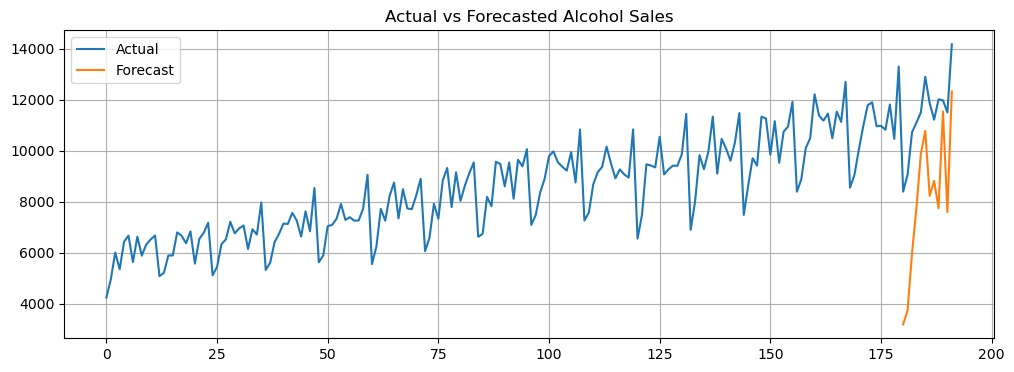

In [217]:
# Start with last known window
future_preds = []
test_inputs = train_norm[-window_size:].tolist()

model.eval()

for i in range(test_size):
    seq = torch.FloatTensor(test_inputs[-window_size:])
    with torch.no_grad():
        model.hidden_cell = torch.zeros(1, 1, model.hidden_layer_size)
        pred = model(seq)
        test_inputs.append(pred.item())
        future_preds.append(pred.item())

# Inverse transform predictions
actual_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1))

# Plot
x = np.arange(len(y))
plt.figure(figsize=(12, 4))
plt.title('Actual vs Forecasted Alcohol Sales')
plt.plot(x, y, label='Actual')
plt.plot(x[-test_size:], actual_preds, label='Forecast')
plt.legend()
plt.grid(True)
plt.show()
